In [28]:
%matplotlib inline
import math
import random
import time
import numpy as np
import torch
from d2l import torch as d2l


In [29]:
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 / sigma**2 * (x - mu)**2)

(1400,)
1400


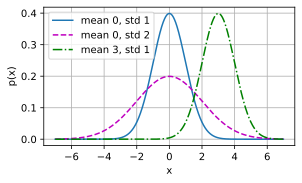

In [30]:
# 再次使用numpy进行可视化
x = np.arange(-7, 7, 0.01)
print(x.shape)
print(len(x))

# 均值和标准差对
params = [(0, 1), (0, 2), (3, 1)]
d2l.plot(x, 
        [normal(x, mu, sigma) for mu, sigma in params],
        xlabel='x',
        ylabel='p(x)', figsize=(4.5, 2.5),
        legend=[f'mean {mu}, std {sigma}' for mu, sigma in params])

In [31]:

# 1. 创建两个整数矩阵
# 使用 dtype=torch.int64 (即 LongTensor)，这是 PyTorch 中最常用的整数类型
matrix_a = torch.tensor([[1, 2], 
                    [3, 4]], dtype=torch.int64)

matrix_b = torch.tensor([[5, 6], 
                        [7, 8]], dtype=torch.int64)

# 2. 执行矩阵乘法
# 方式 A: 使用 torch.matmul()
result_1 = torch.matmul(matrix_a, matrix_b)

# 方式 B: 使用 @ 运算符 (Python 3.5+ 推荐的简洁写法)
result_2 = matrix_a @ matrix_b

# 3. 打印结果
print("矩阵 A:\n", matrix_a)
print("矩阵 B:\n", matrix_b)
print("-" * 20)
print("乘法结果:\n", result_2)

# 验证计算过程：
# [1*5 + 2*7, 1*6 + 2*8] -> [19, 22]
# [3*5 + 4*7, 3*6 + 4*8] -> [43, 50]

矩阵 A:
 tensor([[1, 2],
        [3, 4]])
矩阵 B:
 tensor([[5, 6],
        [7, 8]])
--------------------
乘法结果:
 tensor([[19, 22],
        [43, 50]])


In [32]:
# 1. 生成数据集（人工数据）
def synthetic_data(w, b, num_examples):
    """生成 y = Xw + b + 噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))          # shape: (1000, 2)
    y = torch.matmul(X, w) + b                              # shape: (1000,)
    y += torch.normal(0, 0.01, y.shape)                     # 加噪声
    return X, y.reshape((-1, 1))                            # y 变成列向量 (1000,1)


In [33]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
print(features[0], labels[0])

tensor([ 0.8604, -1.3969]) tensor([10.6559])


In [34]:
# 2. 读取数据集（小批量）
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i:min(i+batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [45]:
# 3. 初始化模型参数
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)   # (2,1)
b = torch.zeros(1, requires_grad=True)
print(w.shape, b.shape)
print(w)
print(b)


torch.Size([2, 1]) torch.Size([1])
tensor([[-0.0009],
        [-0.0040]], requires_grad=True)
tensor([0.], requires_grad=True)


In [46]:
# 4. 定义模型（线性回归的前向计算）
def linreg(X, w, b):
    """线性回归模型：ŷ = Xw + b"""
    return torch.matmul(X, w) + b

In [47]:
# 5. 定义损失函数（均方误差）
def squared_loss(y_hat, y):
    """均方误差：(y_hat - y)^2 / 2 （常省略2，因为求导时会抵消）"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [48]:
# 6. 定义优化算法（小批量随机梯度下降）
def sgd(params, lr, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size   # 重要：除以 batch_size
            param.grad.zero_()

In [ ]:
# 7. 训练过程
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss
batch_size = 10

for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)           # 前向 + 损失
        # print(f'loss shape: {l.shape}')    # 每个小批量的损失
        # print(f'loss: {l}')                 # 每个小批量的损失值
        # w = 0.
        # b = None
        l.sum().backward()                  # 反向传播，计算梯度
        
        sgd([w, b], lr, batch_size)         # 更新参数
        
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')


loss shape: torch.Size([10, 1])
loss: tensor([[2.0603e-05],
        [4.7912e-05],
        [5.1821e-07],
        [6.8363e-05],
        [6.5890e-06],
        [6.5700e-06],
        [4.1764e-06],
        [1.4365e-05],
        [2.7980e-04],
        [3.0839e-05]], grad_fn=<DivBackward0>)
loss shape: torch.Size([10, 1])
loss: tensor([[4.0492e-05],
        [3.8218e-06],
        [5.2230e-05],
        [3.4166e-06],
        [4.4242e-05],
        [7.7207e-07],
        [1.9333e-04],
        [1.1416e-05],
        [7.2190e-05],
        [2.2639e-04]], grad_fn=<DivBackward0>)
loss shape: torch.Size([10, 1])
loss: tensor([[6.4410e-05],
        [3.3814e-05],
        [2.9315e-05],
        [9.3463e-06],
        [7.5755e-06],
        [7.8594e-05],
        [4.6178e-05],
        [1.7703e-04],
        [1.0684e-05],
        [2.1384e-06]], grad_fn=<DivBackward0>)
loss shape: torch.Size([10, 1])
loss: tensor([[4.3842e-06],
        [3.4547e-06],
        [5.0533e-06],
        [4.0241e-05],
        [3.7134e-05],
   

In [51]:
# 自動微分示例

w = torch.tensor(2.0, requires_grad=True)
x = torch.tensor(3.0)
y = w * x           # y = 6.0，但這時只是記錄了「y 是 w 乘 x」
z = y ** 2          # z = 36.0，只是記錄
loss = z + 10       # loss = 46.0，只是記錄

loss.backward()     # 現在才真的開始算梯度！

print(w.grad)       # 輸出 120.0


tensor(36.)
